### Inference for the Variance of a Gaussian Distribution


To perform inference for the variance of a Gaussian distribution, we generate some sample data from a known Gaussian distribution. Then, we can calculate the sample variance as an estimator for the true population variance.

True Mean (mu_true): 0.0 
True Standard Deviation (sigma_true): 2.0 
True Variance (variance_true): 4.0 

Generated 1000 data points.


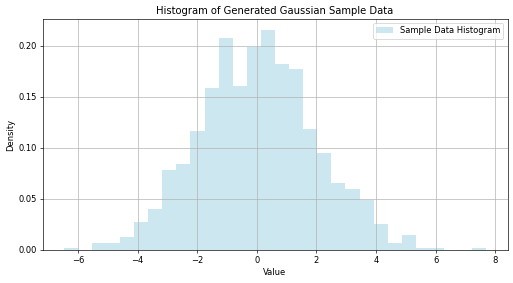

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters of the true Gaussian distribution
mu_true = 0.0  # True mean
sigma_true = 2.0  # True standard deviation
variance_true = sigma_true**2 # True variance

# Generate a sample from the Gaussian distribution
sample_size = 1000
np.random.seed(42) # for reproducibility
data = np.random.normal(loc=mu_true, scale=sigma_true, size=sample_size)

print(f"True Mean (mu_true): {mu_true} \n"
f"True Standard Deviation (sigma_true): {sigma_true} \n"
f"True Variance (variance_true): {variance_true} \n"
f"\nGenerated {sample_size} data points.")

# Plot the histogram of the generated data
plt.figure(figsize=(10, 5), dpi=60)
plt.hist(data, bins=30, density=True, alpha=0.6, color='lightblue', label='Sample Data Histogram')
plt.title('Histogram of Generated Gaussian Sample Data')
plt.xlabel('Value') ; plt.ylabel('Density')
plt.grid(True) ; plt.legend() ; plt.show()

**The sample variance** is an unbiased estimator of the population variance. Calculate the sample variance from the generated data.

In [2]:
# Calculate the sample variance
sample_variance = np.var(data, ddof=1) # ddof=1 for unbiased estimator
sample_std_dev = np.sqrt(sample_variance)

print(f"Sample Mean: {np.mean(data):.4f} \n"
f"Sample Standard Deviation: {sample_std_dev:.4f} \n"
f"Sample Variance: {sample_variance:.4f} \n"
f"True Variance: {variance_true:.4f}")

print(f"\nThe calculated sample variance ({sample_variance:.4f}) is an estimate of the true population variance ({variance_true:.4f}).")

Sample Mean: 0.0387 
Sample Standard Deviation: 1.9584 
Sample Variance: 3.8355 
True Variance: 4.0000

The calculated sample variance (3.8355) is an estimate of the true population variance (4.0000).


**Constructing a Confidence Interval for the Population Variance**

To construct a $(1 - \alpha) \times 100\%$ confidence interval for the population variance $\sigma^2$, we use the chi-squared distribution. The formula for the confidence interval is
- $ \frac{(n-1)s^2}{\chi^2_{\alpha/2, n-1}} \le \sigma^2 \le \frac{(n-1)s^2}{\chi^2_{1-\alpha/2, n-1}} $

Where:
- $n$ is the sample size
- $s^2$ is the sample variance
- $\chi^2_{\alpha/2, n-1}$ is the chi-squared value with $n-1$ degrees of freedom and an area of $\alpha/2$ to its right.
- $\chi^2_{1-\alpha/2, n-1}$ is the chi-squared value with $n-1$ degrees of freedom and an area of $1-\alpha/2$ to its right.

In [3]:
from scipy.stats import chi2

# Confidence level
confidence_level = 0.95
alpha = 1 - confidence_level

# Degrees of freedom
df = sample_size - 1

# Calculate the critical chi-squared values
chi2_lower = chi2.ppf(alpha / 2, df)
chi2_upper = chi2.ppf(1 - alpha / 2, df)

# Calculate the confidence interval for the variance
lower_bound_variance = ((sample_size - 1) * sample_variance) / chi2_upper
upper_bound_variance = ((sample_size - 1) * sample_variance) / chi2_lower

print(f"Confidence Level: {confidence_level*100:.0f}% \n"
f"Degrees of Freedom: {df} \n"
f"Chi-squared lower critical value (alpha/2): {chi2_lower:.4f} \n"
f"Chi-squared upper critical value (1-alpha/2): {chi2_upper:.4f} \n"
f"\n{confidence_level*100:.0f}% Confidence Interval for Population Variance: [{lower_bound_variance:.4f}, {upper_bound_variance:.4f}] \n"
f"True Variance: {variance_true:.4f}")

if lower_bound_variance <= variance_true <= upper_bound_variance:
    print(f"The true variance ({variance_true:.4f}) falls within the {confidence_level*100:.0f}% confidence interval.")
else:
    print(f"The true variance ({variance_true:.4f}) does NOT fall within the {confidence_level*100:.0f}% confidence interval.")

Confidence Level: 95% 
Degrees of Freedom: 999 
Chi-squared lower critical value (alpha/2): 913.3010 
Chi-squared upper critical value (1-alpha/2): 1088.4871 

95% Confidence Interval for Population Variance: [3.5201, 4.1954] 
True Variance: 4.0000
The true variance (4.0000) falls within the 95% confidence interval.


#### Confidence Interval for Population Variance

To better understand the confidence interval, we visualize it along with the true population variance and the sample variance.

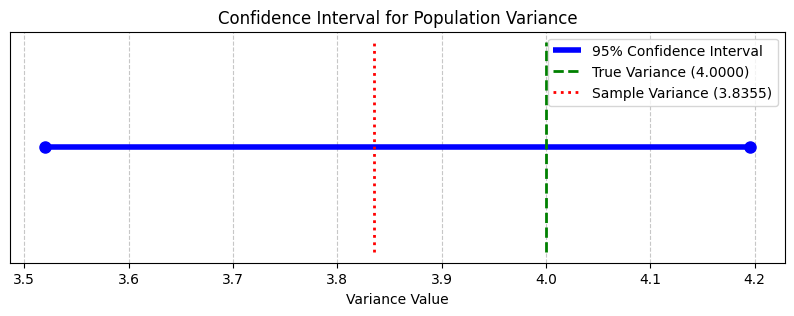

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

# Plot the confidence interval
plt.hlines(y=0.5, xmin=lower_bound_variance, xmax=upper_bound_variance, color='blue', linestyle='-', linewidth=4, label=f'{confidence_level*100:.0f}% Confidence Interval')
plt.plot(lower_bound_variance, 0.5, 'o', color='blue', markersize=8)
plt.plot(upper_bound_variance, 0.5, 'o', color='blue', markersize=8)

# Plot the true variance
plt.vlines(x=variance_true, ymin=0.3, ymax=0.7, color='green', linestyle='--', linewidth=2, label=f'True Variance ({variance_true:.4f})')

# Plot the sample variance
plt.vlines(x=sample_variance, ymin=0.3, ymax=0.7, color='red', linestyle=':', linewidth=2, label=f'Sample Variance ({sample_variance:.4f})')


plt.title('Confidence Interval for Population Variance')
plt.xlabel('Variance Value')
plt.yticks([]) # Remove y-axis ticks
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

#### Calculate Confidence Interval for the Mean
Calculate the confidence interval for the population mean using the provided data and then display the true mean, sample mean, and the calculated confidence interval for the mean, indicating whether the true mean falls within the interval. Finally, visualize this confidence interval alongside the true and sample means, similar to the variance visualization.

In [5]:
from scipy.stats import t

# Calculate sample mean (already available as np.mean(data))
sample_mean = np.mean(data)

# Define the confidence level
confidence_level_mean = 0.95
alpha_mean = 1 - confidence_level_mean

# Calculate degrees of freedom
df_mean = sample_size - 1

# Calculate the critical t-value
t_critical = t.ppf(1 - alpha_mean / 2, df_mean)

# Calculate the standard error of the mean
standard_error_mean = sample_std_dev / np.sqrt(sample_size)

# Calculate the margin of error
margin_of_error = t_critical * standard_error_mean

# Compute the confidence interval for the mean
lower_bound_mean = sample_mean - margin_of_error
upper_bound_mean = sample_mean + margin_of_error

print(f"Confidence Level for Mean: {confidence_level_mean*100:.0f}% \n"
f"Degrees of Freedom for Mean: {df_mean} \n"
f"Critical t-value: {t_critical:.4f} \n"
f"Sample Mean: {sample_mean:.4f} \n"
f"Standard Error of the Mean: {standard_error_mean:.4f} \n"
f"Margin of Error: {margin_of_error:.4f} \n"
f"\n{confidence_level_mean*100:.0f}% Confidence Interval for Population Mean: [{lower_bound_mean:.4f}, {upper_bound_mean:.4f}] \n"
f"True Mean: {mu_true:.4f}")

if lower_bound_mean <= mu_true <= upper_bound_mean:
    print(f"The true mean ({mu_true:.4f}) falls within the {confidence_level_mean*100:.0f}% confidence interval.")
else:
    print(f"The true mean ({mu_true:.4f}) does NOT fall within the {confidence_level_mean*100:.0f}% confidence interval.")

Confidence Level for Mean: 95% 
Degrees of Freedom for Mean: 999 
Critical t-value: 1.9623 
Sample Mean: 0.0387 
Standard Error of the Mean: 0.0619 
Margin of Error: 0.1215 

95% Confidence Interval for Population Mean: [-0.0829, 0.1602] 
True Mean: 0.0000
The true mean (0.0000) falls within the 95% confidence interval.


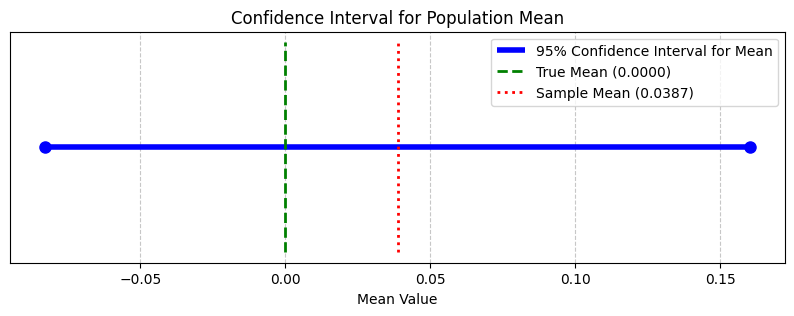

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))

# Plot the confidence interval for the mean
plt.hlines(y=0.5, xmin=lower_bound_mean, xmax=upper_bound_mean, color='blue', linestyle='-', linewidth=4, label=f'{confidence_level_mean*100:.0f}% Confidence Interval for Mean')
plt.plot(lower_bound_mean, 0.5, 'o', color='blue', markersize=8)
plt.plot(upper_bound_mean, 0.5, 'o', color='blue', markersize=8)

# Plot the true mean
plt.vlines(x=mu_true, ymin=0.3, ymax=0.7, color='green', linestyle='--', linewidth=2, label=f'True Mean ({mu_true:.4f})')

# Plot the sample mean
plt.vlines(x=sample_mean, ymin=0.3, ymax=0.7, color='red', linestyle=':', linewidth=2, label=f'Sample Mean ({sample_mean:.4f})')

plt.title('Confidence Interval for Population Mean')
plt.xlabel('Mean Value') ; plt.yticks([]) # Remove y-axis ticks
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(loc='upper right') ; plt.show()

#### Summary

The true mean (0.0000) falls within the calculated 95% confidence interval for the population mean.

*   A 95% confidence level was used for calculating the confidence interval for the mean.
*   Based on a sample size of 1000, the degrees of freedom for the t-distribution were 999, yielding a critical t-value of 1.9623.
*   The sample mean was calculated as 0.0387, while the true mean was 0.0000.
*   The standard error of the mean was 0.0619, resulting in a margin of error of 0.1215.
*   The 95% confidence interval for the population mean was determined to be [-0.0829, 0.1602].
*   The true mean (0.0000) was successfully contained within this calculated 95% confidence interval.


*   The successful capture of the true mean within the confidence interval demonstrates the reliability of the confidence interval approach in estimating population parameters from sample data.
*   Future analysis could explore how varying the confidence level (e.g., 90% or 99%) or sample size impacts the width of the confidence interval and its ability to contain the true population mean.
